# An analysis of the Glamsterdam 200M gas limit simulation

#### Maria Silva, September 2026

A full-range sweep of the Fusaka -> Glamsterdam gas-limit simulator, run
`20260907T122124Z`, over mainnet blocks 25,168,786-25,319,985 (~21 days,
151,200 block numbers, including empty blocks without transaction cohorts).
Each grid cell runs 50 resampled paths of 7,200 simulated blocks — one day of
chain time — while the gas limit ramps from 60M to 200M at
1/1024 per block.

The grid is elasticity {0.1, 0.2, 0.3} x demand level {1, 1.5, 2, 2.5}, 12 cells
in all. No cell hit the `MAX_BASE_FEE` or demand-multiplier guards over the full day.
The results remain conditional on the modelling assumptions below.

The time-series sections focus on the **first 3,000 blocks**, which covers the
whole gas-limit ramp (it ends at block 1,234) and the settling after it. The
appendix shows the full day, including the remaining 4,200 blocks.

**Measurement window.** Settled-period statistics use blocks 3,000–7,199, after
fees and utilization have approximately stabilised in all scenarios. The
convergence check below compares the two halves of this window. The simulation
covers one day under fixed demand assumptions and a frozen transaction mix.

In [1]:
import glob
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 15}
)

# The per-cell tables are 12 rows long; show them whole
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

In [3]:
# Main directories
current_path = os.getcwd()
repo_dir = os.path.abspath(current_path)
output_dir = os.path.join(repo_dir, "output")
analysis_dir = os.path.join(output_dir, "analysis", "20260907T122124Z")
os.makedirs(analysis_dir, exist_ok=True)
# Figures are written straight into the report's figure directory, so
# rerunning this notebook refreshes exactly what the report renders
figs_dir = os.path.join(repo_dir, "reports", "figures", "gas_limit_simulation")
os.makedirs(figs_dir, exist_ok=True)

# The run this notebook analyses
run_dirs = [os.path.join(output_dir, "20260907T122124Z")]

zoom_blocks = 3000   # the transient window for the zoomed time series
steady_start = 3000  # inclusive start of the settled-period statistics
excluded_levels = []  # nothing hit a guard in this run
gas_limit = 200_000_000

# Run constants, taken from the manifest rather than hardcoded
with open(os.path.join(run_dirs[0], "manifest.json"), "r") as file:
    manifest = json.load(file)
    resolved = manifest["resolved"]

start_fee_gwei = resolved["starting_base_fee_wei"] / 1e9  # base fee at block 0
anchor_fee_gwei = resolved["demand_anchor_price_wei"] / 1e9  # price the curve is anchored at
reference_gas = resolved["demand_reference_gas"]  # mean cohort gas, the demand unit
print(f"starting base fee   {start_fee_gwei:.4f} gwei")
print(f"demand anchor price {anchor_fee_gwei:.4f} gwei")
print(f"reference gas       {reference_gas:,.0f}")
horizon = resolved["simulation_horizon_blocks"]  # blocks per path
print(f"horizon             {horizon:,} blocks")

starting base fee   0.0847 gwei
demand anchor price 1.0130 gwei
reference gas       61,334,918
horizon             7,200 blocks


## Load and process data

Run this notebook from the repository root with the saved run under `output/`.
It needs the simulation dependencies plus `seaborn`, `matplotlib`, and a Jupyter
kernel. It reads saved results only; no credentials or new simulation are needed.

Three cached tables serve different purposes:

- `steps_df`: individual blocks before position 3,000, for the transition plots.
- `window_df`: 24-block means within each path over the full day.
- `steady_df`: a reproducible sample of 20,000 individual blocks per scenario
  from positions 3,000–7,199, used for medians and distributions.

Caches live in a directory named for this run; filenames identify their windows.
Delete that directory if the source results or metric definitions change.
The full-run audit below reads the original parts, independent of these caches.
Figures are refreshed in `reports/figures/gas_limit_simulation/`.
All block positions are zero-based; times assume 12 seconds per block.

In [4]:
steps_file = os.path.join(analysis_dir, f"steps_0_{zoom_blocks}.parquet")
window_file = os.path.join(analysis_dir, f"window_0_{horizon}.parquet")
steady_file = os.path.join(analysis_dir, f"steady_{steady_start}_{horizon}.parquet")

metrics = [
    "utilization", "execution_utilization", "state_utilization",
    "base_fee_gwei", "demand_multiplier", "tip_gwei",
    "backlog_txs", "eligible_backlog_txs",
    "base_fee_clamped", "demand_multiplier_clamped", "ramp_end_block",
]
keys = ["elasticity", "demand_level", "demand", "run_index"]

if all(os.path.exists(path) for path in (steps_file, window_file, steady_file)):
    steps_df = pd.read_parquet(steps_file)
    window_df = pd.read_parquet(window_file)
    steady_df = pd.read_parquet(steady_file)
else:
    steps_list, window_list, steady_list = [], [], []
    for run_dir in run_dirs:
        for file_path in sorted(glob.glob(os.path.join(run_dir, "per_step", "*.parquet"))):
            # File stems look like e0.1_d1.5_p16
            stem = os.path.basename(file_path).replace(".parquet", "")
            elasticity, demand_level, pool_blocks = [float(p[1:]) for p in stem.split("_")]
            if demand_level in excluded_levels:
                continue
            print(f"reading {stem}", flush=True)

            df = pd.read_parquet(file_path)
            # A block's gas used is max(execution, state): they share one limit
            df["gas_used"] = np.maximum(df["block_execution_gas_used"], df["block_state_gas_used"])
            df["utilization"] = df["gas_used"] / df["gas_limit"]
            df["execution_utilization"] = df["block_execution_gas_used"] / df["gas_limit"]
            df["state_utilization"] = df["block_state_gas_used"] / df["gas_limit"]
            df["base_fee_gwei"] = df["base_fee_per_gas"] / 1e9
            df["demand_multiplier"] = df["realized_demand_multiplier"]
            df["tip_gwei"] = df["priority_fees_wei"] / df["sender_gas_used"].clip(lower=1) / 1e9
            df["backlog_txs"] = df["backlog_tx_count"]
            df["eligible_backlog_txs"] = df["backlog_eligible_tx_count"]
            df["elasticity"] = elasticity
            df["demand_level"] = demand_level
            df["demand"] = f"{demand_level:g}x"
            # The ramp is over once the limit first reaches its ceiling
            df["ramp_end_block"] = df.loc[
                df["gas_limit"] == df["gas_limit"].max(), "simulation_position"
            ].min()

            # The transient, block by block. No binning, so the band seaborn draws
            # is the real spread across the resampled paths at each single block
            zoom = df[df["simulation_position"] < zoom_blocks].copy()
            zoom["block"] = zoom["simulation_position"]
            steps_list.append(zoom[keys + ["block"] + metrics])

            # The full horizon, binned to ~300 points, for the appendix
            bin_width = max(1, (df["simulation_position"].max() + 1) // 300)
            df["block"] = df["simulation_position"] // bin_width * bin_width
            window_list.append(df.groupby(keys + ["block"], as_index=False)[metrics].mean())

            # Sample individual blocks from the settled period, retaining positions
            # so the cached sample can be checked against the selected window.
            settled = df[df["simulation_position"].between(steady_start, horizon - 1)]
            steady_list.append(settled.sample(20_000, random_state=0)[
                keys + ["simulation_position"] + metrics
            ])

    steps_df = pd.concat(steps_list, ignore_index=True)
    window_df = pd.concat(window_list, ignore_index=True)
    steady_df = pd.concat(steady_list, ignore_index=True)
    steps_df.to_parquet(steps_file, index=False)
    window_df.to_parquet(window_file, index=False)
    steady_df.to_parquet(steady_file, index=False)

assert steady_df["simulation_position"].between(steady_start, horizon - 1).all()
assert steady_df.groupby(["elasticity", "demand_level"]).size().eq(20_000).all()
print(f"settled-period sample: blocks {steady_start:,}–{horizon - 1:,}, 20,000 per cell")

demand_order = sorted(steps_df["demand"].unique(), key=lambda s: float(s[:-1]))
ramp_end = int(steps_df["ramp_end_block"].max())
n_paths = steps_df["run_index"].nunique()
print(f"resampled paths per cell: {n_paths}")
print(f"ramp ends at block {ramp_end:,}")
steps_df.info()

reading e0.1_d1.0_p16


reading e0.1_d1.5_p16


reading e0.1_d2.0_p16


reading e0.1_d2.5_p16


reading e0.2_d1.0_p16


...

reading e0.3_d1.0_p16


reading e0.3_d1.5_p16


reading e0.3_d2.0_p16


reading e0.3_d2.5_p16


settled-period sample: blocks 3,000–7,199, 20,000 per cell
resampled paths per cell: 50
ramp ends at block 1,234
<class 'pandas.DataFrame'>
RangeIndex: 1800000 entries, 0 to 1799999
Data columns (total 16 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   elasticity                 float64
 1   demand_level               float64
 2   demand                     str    
 3   run_index                  int64  
 4   block                      int64  
 5   utilization                float64
 6   execution_utilization      float64
 7   state_utilization          float64
 8   base_fee_gwei              float64
 9   demand_multiplier          float64
 10  tip_gwei                   float64
 11  backlog_txs                int64  
 12  eligible_backlog_txs       int64  
 13  base_fee_clamped           bool   
 14  demand_multiplier_clamped  bool   
 15  ramp_end_block             int64  
dtypes: bool(2), float64(8), int64(5), str(1)
memory usage: 201.1

### One row per grid cell

Each row contains medians across the sampled individual blocks, except
`saturated_share`, which is the fraction using at least 99% of the limit.
`tip_gwei` is the median of block-level gas-weighted mean tips, not the median
transaction tip. Queue counts are measured after inclusion.

For descriptive grouping, "near target" means median utilisation within one
percentage point of 50%. The approximate target demand multiplier is the median
of those scenarios' median multipliers; it is an observed reference, not a cap.

In [5]:
cells_df = (
    steady_df.groupby(["elasticity", "demand_level", "demand"])
    .agg(
        utilization=("utilization", "median"),
        execution_utilization=("execution_utilization", "median"),
        state_utilization=("state_utilization", "median"),
        base_fee_gwei=("base_fee_gwei", "median"),
        tip_gwei=("tip_gwei", "median"),
        demand_multiplier=("demand_multiplier", "median"),
        backlog_txs=("backlog_txs", "median"),
        eligible_backlog_txs=("eligible_backlog_txs", "median"),
        saturated_share=("utilization", lambda s: (s >= 0.99).mean()),
    )
    .reset_index()
)
# Classify by utilisation itself, independently of the demand multiplier.
cells_df["regime"] = np.where(
    cells_df["utilization"].sub(0.5).abs() <= 0.01, "near target", "below target"
)
target_multiplier = cells_df.loc[
    cells_df["regime"] == "near target", "demand_multiplier"
].median()
cells_df.round(4)

,elasticity,demand_level,demand,utilization,execution_utilization,state_utilization,base_fee_gwei,tip_gwei,demand_multiplier,backlog_txs,eligible_backlog_txs,saturated_share,regime
0,0.1,1.0,1x,0.2826,0.2726,0.1614,0.0000,0.0245,1.3970,0.0,0.0,0.0,below target
1,0.1,1.5,1.5x,0.4140,0.4029,0.2460,0.0000,0.0250,2.0960,0.0,0.0,0.0,below target
2,0.1,2.0,2x,0.4977,0.4858,0.3016,0.0059,0.0756,2.5369,0.0,0.0,0.0,near target
3,0.1,2.5,2.5x,0.4990,0.4870,0.2998,0.3199,0.3806,2.5372,0.0,0.0,0.0,near target
4,0.2,1.0,1x,0.3872,0.3755,0.2299,0.0000,0.0249,1.9547,0.0,0.0,0.0,below target
5,0.2,1.5,1.5x,0.4973,0.4847,0.3019,0.0021,0.0607,2.5368,0.0,0.0,0.0,near target
6,0.2,2.0,2x,0.4970,0.4845,0.3013,0.0609,0.1929,2.5365,0.0,0.0,0.0,near target
7,0.2,2.5,2.5x,0.4984,0.4856,0.3000,0.3722,0.3862,2.5362,161.0,0.0,0.0,near target
8,0.3,1.0,1x,0.4978,0.4838,0.3014,0.0002,0.0350,2.5416,0.0,0.0,0.0,near target
9,0.3,1.5,1.5x,0.4986,0.4864,0.2996,0.0258,0.1241,2.5360,0.0,0.0,0.0,near target


### Full-run checks

Check every block for clamping, including those outside the plotted transition.
A bound being hit needs investigation before interpreting the affected result.
This audit also measures which gas dimension is larger and how much eligible
backlog remains, so later takeaways do not infer maxima from medians.

In [6]:
audit_rows = []
for run_dir in run_dirs:
    for file_path in sorted(glob.glob(os.path.join(run_dir, "per_step", "*.parquet"))):
        raw = pd.read_parquet(file_path, columns=[
            "aggregate_elasticity", "demand_level", "simulation_position", "gas_limit",
            "block_execution_gas_used", "block_state_gas_used", "base_fee_clamped",
            "demand_multiplier_clamped", "backlog_eligible_tx_count", "backlog_tx_count",
        ])
        settled = raw[raw["simulation_position"].between(steady_start, horizon - 1)]
        audit_rows.append({
            "elasticity": raw["aggregate_elasticity"].iloc[0],
            "demand_level": raw["demand_level"].iloc[0],
            "base_fee_clamped_share": raw["base_fee_clamped"].mean(),
            "multiplier_clamped_share": raw["demand_multiplier_clamped"].mean(),
            "state_larger_share": (raw["block_state_gas_used"] > raw["block_execution_gas_used"]).mean(),
            "settled_state_larger_share": (settled["block_state_gas_used"] > settled["block_execution_gas_used"]).mean(),
            "max_state_utilization": (raw["block_state_gas_used"] / raw["gas_limit"]).max(),
            "max_eligible_backlog": raw["backlog_eligible_tx_count"].max(),
            "settled_max_eligible_backlog": settled["backlog_eligible_tx_count"].max(),
            "settled_eligible_backlog_share": (settled["backlog_eligible_tx_count"] > 0).mean(),
            "terminal_max_backlog": raw.loc[raw["simulation_position"] == horizon - 1, "backlog_tx_count"].max(),
        })
        del raw, settled
run_audit_df = pd.DataFrame(audit_rows)
clamp_columns = ["base_fee_clamped_share", "multiplier_clamped_share"]
print("cells with any clamping:", run_audit_df[clamp_columns].gt(0).any(axis=1).sum())
assert run_audit_df[clamp_columns].eq(0).all().all()
print(f"the 1/1024 ramp reaches 200M at block {ramp_end:,}")
run_audit_df[["elasticity", "demand_level"] + clamp_columns]

cells with any clamping: 0
the 1/1024 ramp reaches 200M at block 1,234


,elasticity,demand_level,base_fee_clamped_share,multiplier_clamped_share
0,0.1,1.0,0.0,0.0
1,0.1,1.5,0.0,0.0
2,0.1,2.0,0.0,0.0
3,0.1,2.5,0.0,0.0
4,0.2,1.0,0.0,0.0
5,0.2,1.5,0.0,0.0
6,0.2,2.0,0.0,0.0
7,0.2,2.5,0.0,0.0
8,0.3,1.0,0.0,0.0
9,0.3,1.5,0.0,0.0


## Block utilization

`utilization = max(execution_gas, state_gas) / gas_limit`, since the two gas
dimensions share one limit. The line is the mean across the 50 resampled paths and
the band their 10th-90th percentile at each block. The dashed rules are the EIP-1559 target
(50% of the limit) and the block where the ramp ends.

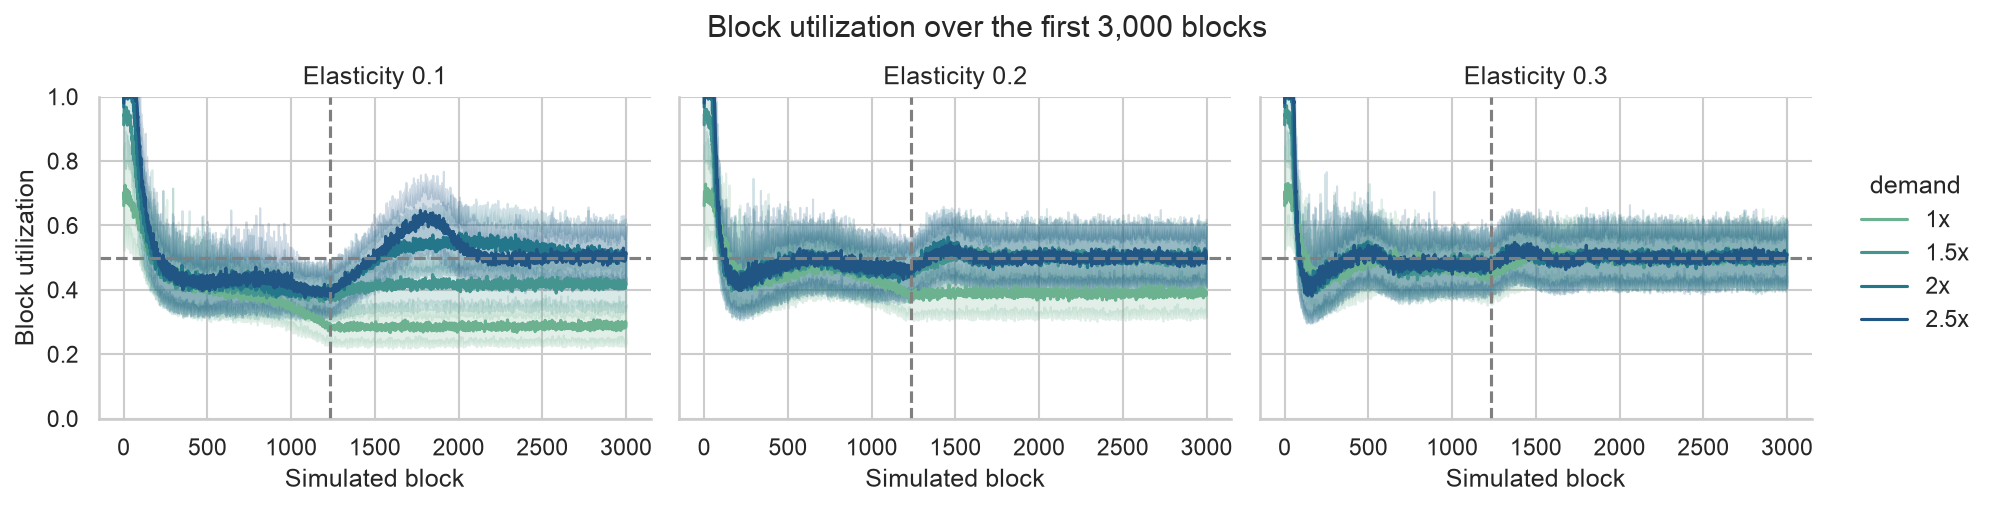

In [7]:
g = sns.relplot(
    data=steps_df,
    kind="line",
    x="block",
    y="utilization",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=0.5, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(ylim=(0, 1), xlabel="Simulated block", ylabel="Block utilization")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Block utilization over the first {zoom_blocks:,} blocks", y=1.05)
plt.savefig(os.path.join(figs_dir, "block_utilization.png"), bbox_inches="tight")
plt.show()

In [8]:
cells_df.pivot(index="demand", columns="elasticity", values="utilization").reindex(demand_order).round(3)

elasticity,0.1,0.2,0.3
demand,,,
1x,0.283,0.387,0.498
1.5x,0.414,0.497,0.499
2x,0.498,0.497,0.497
2.5x,0.499,0.498,0.497


### Takeaways

- **Nine scenarios settle near the 50% fee target**, with median utilisation
  of 49.7–49.9%. Individual blocks can exceed the target.
- **High-demand scenarios initially fill blocks close to the 60M limit.** At
  2.5x, the initial demand target is about 153M gas on the `execution + state`
  basis. That sum cannot be compared directly with the capacity limit, which
  applies separately to each dimension. Arrivals also change as prices respond.
- **The low-elasticity panel shows a post-ramp rebound**, most visibly in the
  higher-demand scenarios around blocks 1,500–1,800. Demand recovers as prices
  fall, while the capacity target has stopped growing; fee feedback then adjusts.
- **Three scenarios remain below target:** `(e=0.1, 1x)`, `(e=0.1, 1.5x)` and
  `(e=0.2, 1x)`, with medians of 28.3%, 41.4% and 38.7%. Their price response
  does not attract enough demand even with a negligible base fee.

## Base fee

The same scenarios on a logarithmic price axis. Similar settled utilisation
can coexist with base fees spanning several orders of magnitude.

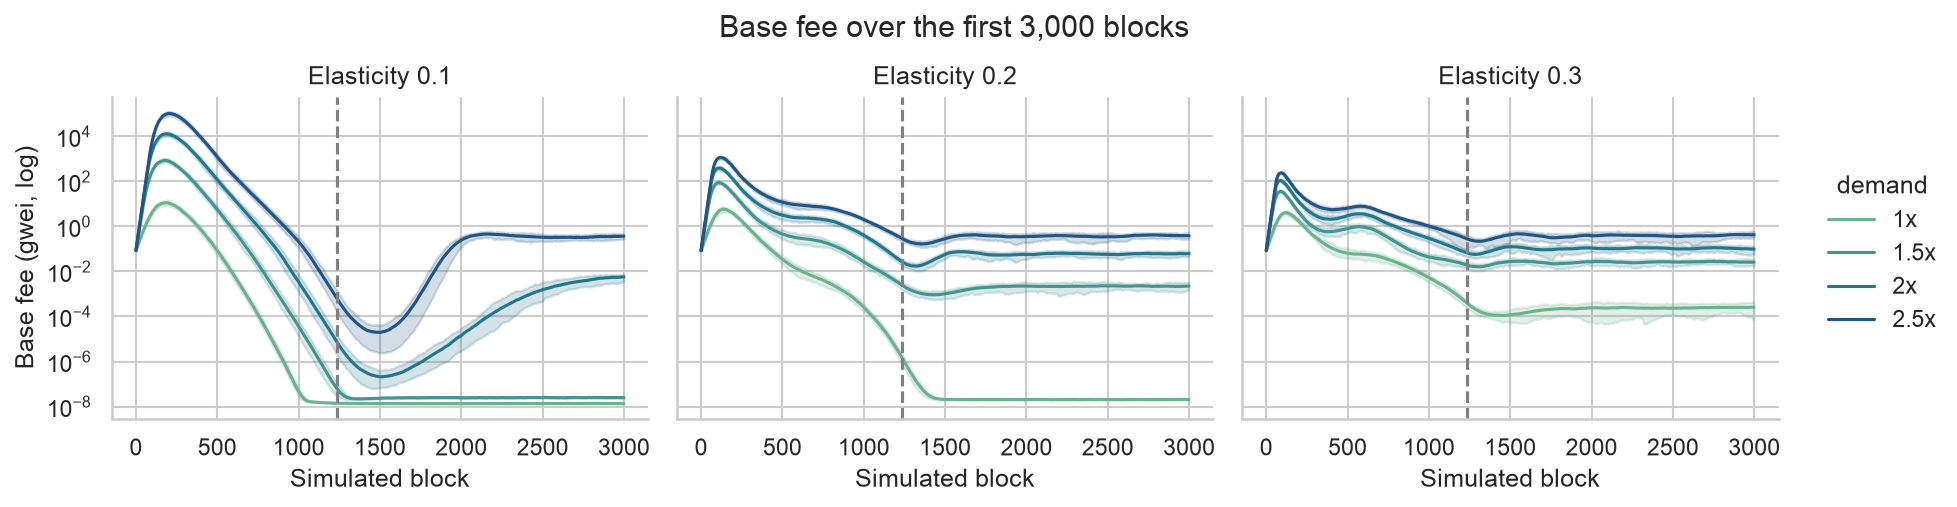

In [9]:
g = sns.relplot(
    data=steps_df,
    kind="line",
    x="block",
    y="base_fee_gwei",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(x=ramp_end, color="grey")
g.set(yscale="log", xlabel="Simulated block", ylabel="Base fee (gwei, log)")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Base fee over the first {zoom_blocks:,} blocks", y=1.05)
plt.savefig(os.path.join(figs_dir, "base_fee.png"), bbox_inches="tight")
plt.show()

In [10]:
cells_df.pivot(index="demand", columns="elasticity", values="base_fee_gwei").reindex(demand_order).round(4)

elasticity,0.1,0.2,0.3
demand,,,
1x,0.0000,0.0000,0.0002
1.5x,0.0000,0.0021,0.0258
2x,0.0059,0.0609,0.1058
2.5x,0.3199,0.3722,0.3928


### Takeaways

- **Similar utilisation can come with very different base fees.** The nine
  near-target scenarios have median base fees of about 0.0002–0.39 gwei,
  spanning more than three orders of magnitude.
- **The initial fee spike is much larger than the settled fee.** Capacity starts
  at 60M, each demand level applies immediately, and the price signal responds
  with a 200-block EMA span. These assumptions allow arrivals to stay high
  while the base fee rises. Higher elasticity produces an earlier, smaller peak.
- **The peak is not a forecast.** This run does not test gradual demand growth
  or other response delays, so it cannot quantify how those choices would change
  the spike or the later adjustment. The three below-target scenarios remain
  at negligible fees rather than recovering to an appreciable clearing price.

## Demand response

`demand_multiplier` is the target arrival quantity in multiples of the trace-average
`execution + state` gas per block: `demand_level * (price_signal / reference_price) ** -elasticity`. It starts
at exactly `demand_level`, because the price signal is seeded at the reference
price, and is thereafter driven by the smoothed effective price (base fee plus the
realised gas-weighted mean tip). The price-response factor is clipped to
[0.05, 20] before multiplying by `demand_level`; no bound binds in this run.
Sampling retains the transaction that crosses the gas target, so realised
arrived gas can slightly exceed this target.

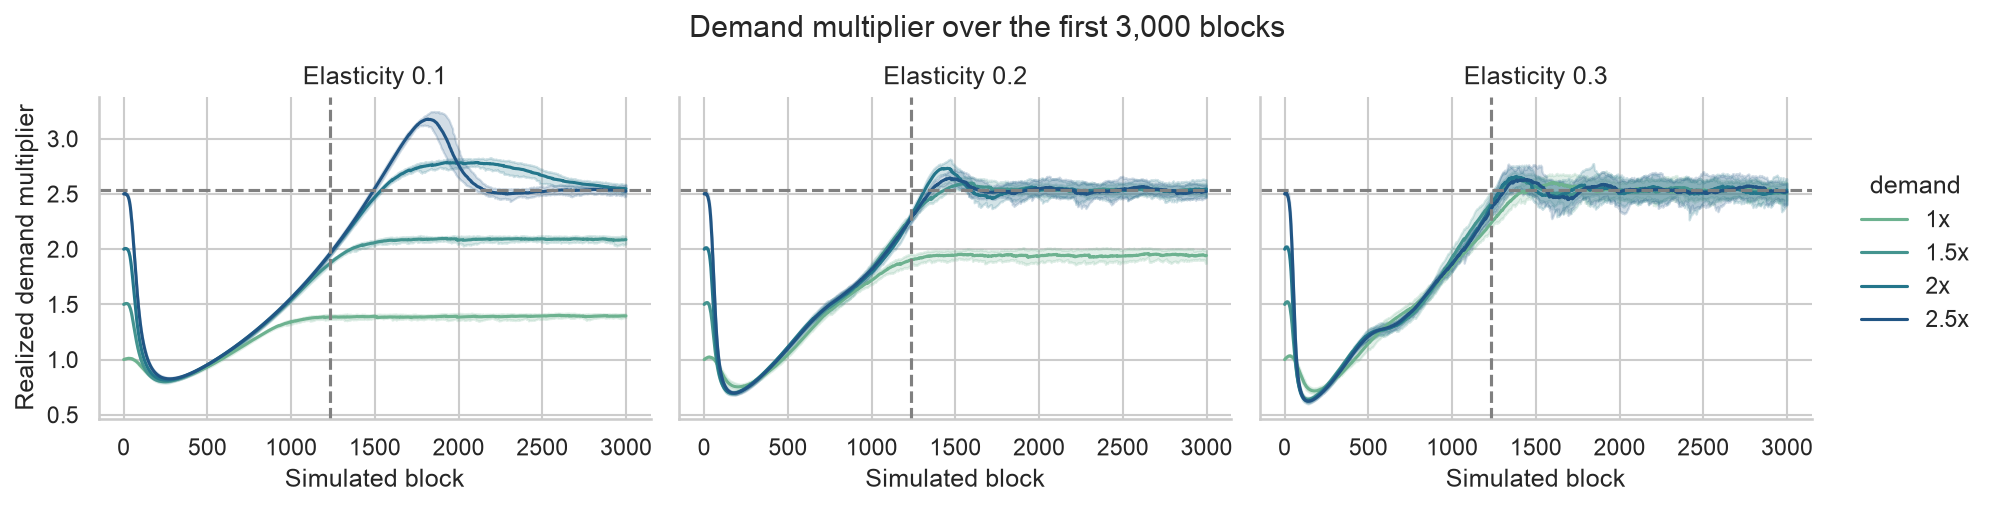

In [11]:
g = sns.relplot(
    data=steps_df,
    kind="line",
    x="block",
    y="demand_multiplier",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=target_multiplier, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(xlabel="Simulated block", ylabel="Realized demand multiplier")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Demand multiplier over the first {zoom_blocks:,} blocks", y=1.05)
plt.savefig(os.path.join(figs_dir, "demand_response.png"), bbox_inches="tight")
plt.show()

In [12]:
# A rough conversion between target demand and included capacity.
# Both quantities below use scenario medians from this run: this is a descriptive
# consistency check, not an independent estimate of the gas mix or a proof.
implied_phi = (gas_limit / 2) / (target_multiplier * reference_gas)
observed_phi = (cells_df["utilization"] * gas_limit) / (cells_df["demand_multiplier"] * reference_gas)
print(f"approximate target multiplier = {target_multiplier:.4f}")
print(f"conversion implied by 100M target = {implied_phi:.4f}")
print(f"ratio of observed medians = {observed_phi.median():.4f} "
      f"(range {observed_phi.min():.4f}-{observed_phi.max():.4f})")
cells_df[["elasticity", "demand", "regime", "demand_multiplier", "utilization", "base_fee_gwei"]].round(4)

approximate target multiplier = 2.5368
conversion implied by 100M target = 0.6427
ratio of observed medians = 0.6402 (range 0.6386-0.6595)


,elasticity,demand,regime,demand_multiplier,utilization,base_fee_gwei
0,0.1,1x,below target,1.3970,0.2826,0.0000
1,0.1,1.5x,below target,2.0960,0.4140,0.0000
2,0.1,2x,near target,2.5369,0.4977,0.0059
3,0.1,2.5x,near target,2.5372,0.4990,0.3199
4,0.2,1x,below target,1.9547,0.3872,0.0000
5,0.2,1.5x,near target,2.5368,0.4973,0.0021
6,0.2,2x,near target,2.5365,0.4970,0.0609
7,0.2,2.5x,near target,2.5362,0.4984,0.3722
8,0.3,1x,near target,2.5416,0.4978,0.0002
9,0.3,1.5x,near target,2.5360,0.4986,0.0258


### Takeaways

- **Nine scenarios settle at roughly 2.54 times the reference demand quantity.**
  Under this mix, that corresponds approximately to the 100M fee target on the
  `max(execution, state)` capacity basis. The conversion above is descriptive:
  ratios of medians do not establish an exact arrival–inclusion balance.
- **The target is not a cap.** Demand and individual-block utilisation can
  exceed it. Fee feedback brings the nine sufficiently high-demand scenarios
  back towards 50% utilisation, at different prices.
- The three below-target scenarios settle at multipliers of about 1.40
  (`e=0.1, 1x`), 2.10 (`e=0.1, 1.5x`) and 1.95 (`e=0.2, 1x`). At `e=0.3`,
  even the 1x scenario attracts enough demand to approach the target.

## Execution vs. state gas

Two capacity constraints share one limit. Shown at the highest included demand
level, where the pressure is greatest.

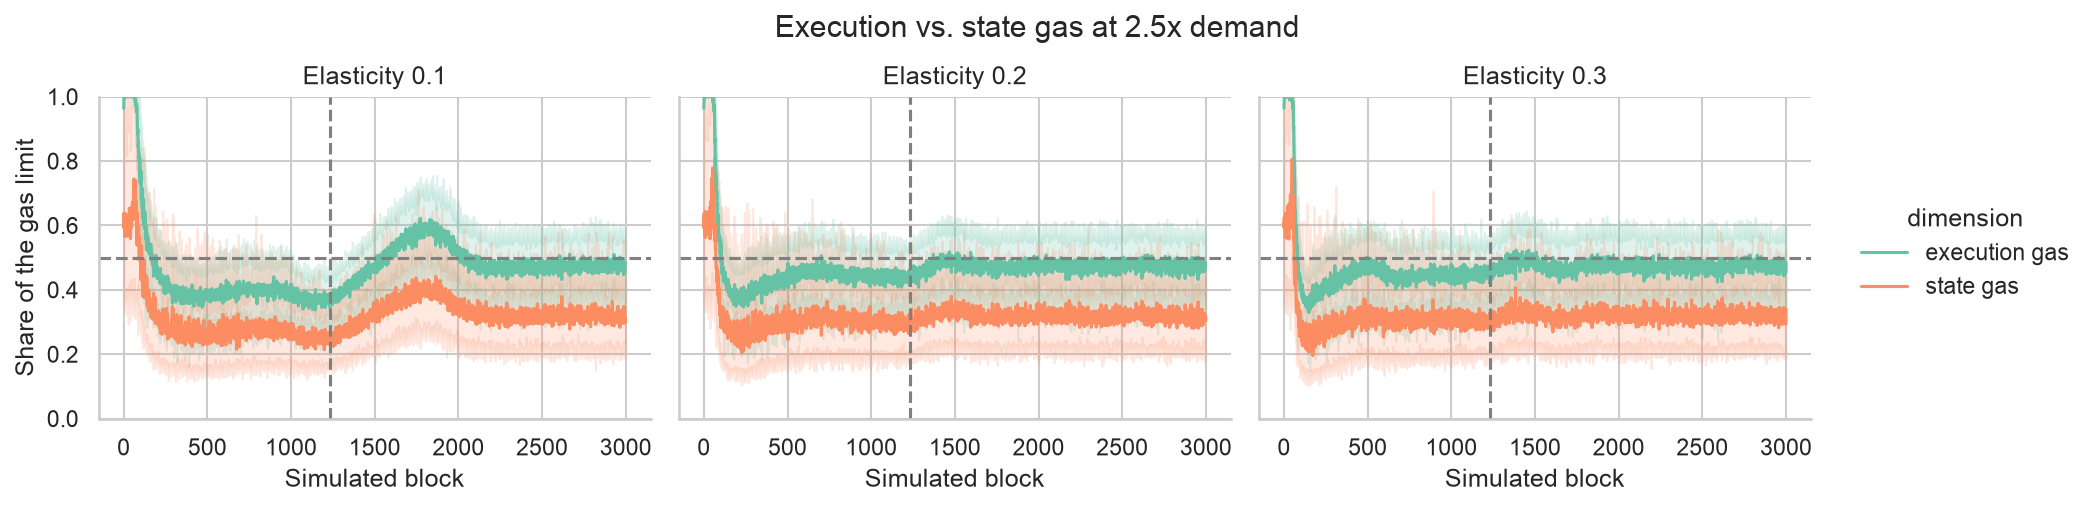

In [13]:
dims_df = steps_df.melt(
    id_vars=["elasticity", "demand", "run_index", "block"],
    value_vars=["execution_utilization", "state_utilization"],
    var_name="dimension",
    value_name="share_of_limit",
)
dims_df["dimension"] = dims_df["dimension"].map(
    {"execution_utilization": "execution gas", "state_utilization": "state gas"}
)

g = sns.relplot(
    data=dims_df[dims_df["demand"] == demand_order[-1]],
    kind="line",
    x="block",
    y="share_of_limit",
    hue="dimension",
    col="elasticity",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=0.5, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(ylim=(0, 1), xlabel="Simulated block", ylabel="Share of the gas limit")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Execution vs. state gas at {demand_order[-1]} demand", y=1.05)
plt.savefig(os.path.join(figs_dir, "execution_vs_state_gas.png"), bbox_inches="tight")
plt.show()

In [14]:
print("median across scenarios of state/execution median utilisation:",
      round((cells_df["state_utilization"] / cells_df["execution_utilization"]).median(), 3))
run_audit_df[["elasticity", "demand_level", "state_larger_share",
              "settled_state_larger_share", "max_state_utilization"]].round(4)

median across scenarios of state/execution median utilisation: 0.619


,elasticity,demand_level,state_larger_share,settled_state_larger_share,max_state_utilization
0,0.1,1.0,0.2120,0.2113,1.0
1,0.1,1.5,0.2012,0.1989,1.0
2,0.1,2.0,0.1917,0.1890,1.0
3,0.1,2.5,0.1910,0.1880,1.0
4,0.2,1.0,0.2025,0.2001,1.0
5,0.2,1.5,0.1928,0.1889,1.0
6,0.2,2.0,0.1916,0.1894,1.0
7,0.2,2.5,0.1905,0.1886,1.0
8,0.3,1.0,0.1930,0.1887,1.0
9,0.3,1.5,0.1923,0.1886,1.0


### Takeaways

- **Execution is usually the larger dimension, but state is larger in 19–21% of
  blocks.** State utilisation sometimes reaches almost 100% during the full run.
  The roughly 62% figure is the median across scenarios of the ratio of their
  separate settled state and execution medians; it does not describe every block.
  Both capacity constraints matter.
- **85.3% of the trace's state gas is in `schedule_gas_rescuable` rows**
  (`replay_outcome_summary.csv`). Including that demand assumes senders raise
  their signed gas limits sufficiently; the model does not predict this adaptation.

## Backlog

Compare total and fee-eligible transactions waiting after block inclusion.
The plots show the transition at 2.5x demand. The scenario summary above reports
settled-period medians; the audit below checks maxima and terminal queues.

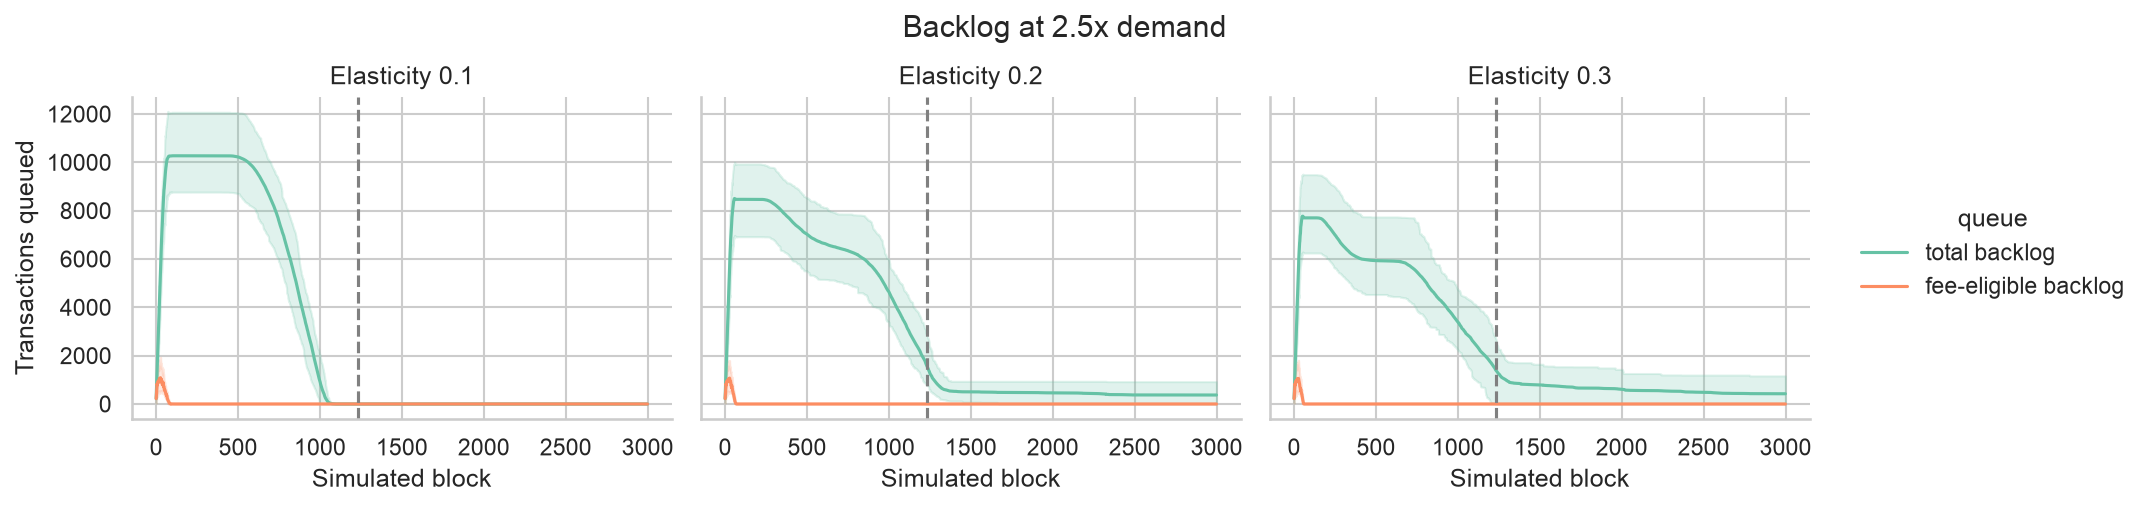

In [15]:
queue_df = steps_df.melt(
    id_vars=["elasticity", "demand", "run_index", "block"],
    value_vars=["backlog_txs", "eligible_backlog_txs"],
    var_name="queue",
    value_name="transactions",
)
queue_df["queue"] = queue_df["queue"].map(
    {"backlog_txs": "total backlog", "eligible_backlog_txs": "fee-eligible backlog"}
)

g = sns.relplot(
    data=queue_df[queue_df["demand"] == demand_order[-1]],
    kind="line",
    x="block",
    y="transactions",
    hue="queue",
    col="elasticity",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(x=ramp_end, color="grey")
g.set(xlabel="Simulated block", ylabel="Transactions queued")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Backlog at {demand_order[-1]} demand", y=1.05)
plt.savefig(os.path.join(figs_dir, "backlog.png"), bbox_inches="tight")
plt.show()

In [16]:
print("largest settled-period median fee-eligible backlog:", cells_df["eligible_backlog_txs"].max())
print("largest eligible backlog over the full day:", run_audit_df["max_eligible_backlog"].max())
print("largest eligible backlog in the full settled window:", run_audit_df["settled_max_eligible_backlog"].max())
print("largest terminal total backlog:", run_audit_df["terminal_max_backlog"].max())
run_audit_df[["elasticity", "demand_level", "settled_max_eligible_backlog",
              "settled_eligible_backlog_share", "terminal_max_backlog"]]

largest settled-period median fee-eligible backlog: 0.0
largest eligible backlog over the full day: 3206
largest eligible backlog in the full settled window: 44
largest terminal total backlog: 1170


,elasticity,demand_level,settled_max_eligible_backlog,settled_eligible_backlog_share,terminal_max_backlog
0,0.1,1.0,0,0.000000,0
1,0.1,1.5,0,0.000000,0
2,0.1,2.0,1,0.000033,0
3,0.1,2.5,2,0.000033,0
4,0.2,1.0,0,0.000000,0
5,0.2,1.5,1,0.000033,0
6,0.2,2.0,44,0.000048,0
7,0.2,2.5,13,0.000038,1012
8,0.3,1.0,1,0.000024,0
9,0.3,1.5,32,0.000057,0


### Takeaways

- **Typical settled queues are small.** Ten scenarios have a zero median total
  backlog in the sample; the other two have medians of 161 transactions
  (`e=0.2, 2.5x`) and 31 (`e=0.3, 2.5x`).
- **A zero median eligible backlog does not mean no queues ever form.** Across
  all original blocks, eligible backlog reaches 3,206 during the transition.
  After block 3,000 it never exceeds 44 and occurs in fewer than 0.006% of blocks
  in each scenario. This supports little sustained capacity pressure in the
  settled window, while allowing temporary queues.
- Remaining settled backlog is overwhelmingly fee-ineligible. Bids adapt only
  when transactions arrive, so an item can become ineligible after the fee rises.
  The largest terminal total backlog across all paths is 1,170 transactions.
  These transactions are still unmet demand at their stored fee caps.

## Settled base fee by demand level

At the same 200M limit, compare the base fees supported by different demand
assumptions. Three scenarios stay below target at negligible fees; the other
nine approach 50% utilisation at different prices.

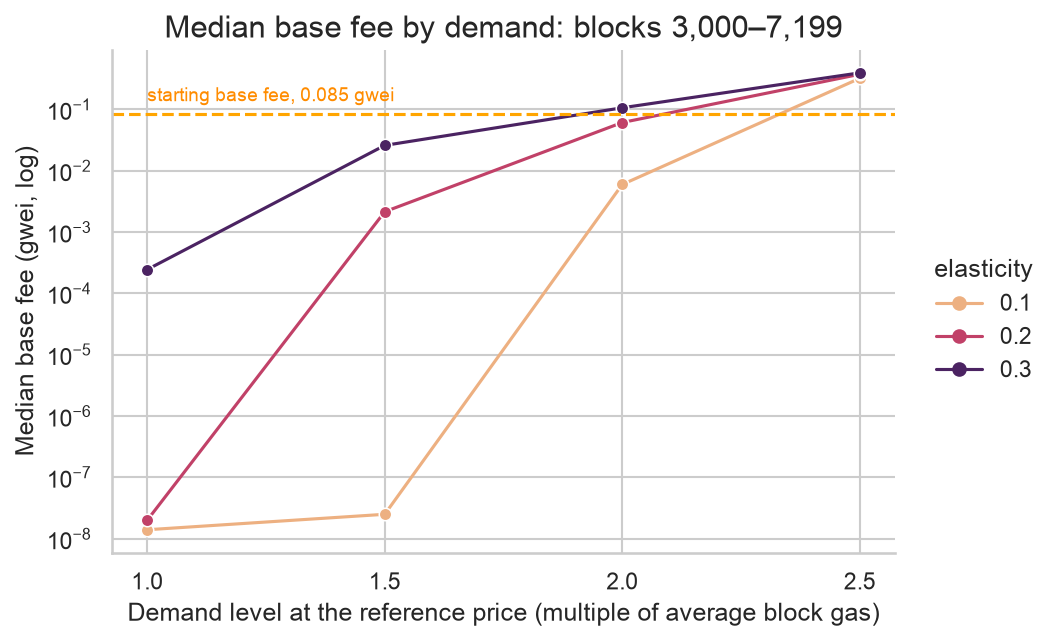

In [17]:
g = sns.relplot(
    data=cells_df,
    kind="line",
    x="demand_level",
    y="base_fee_gwei",
    hue="elasticity",
    palette="flare",
    marker="o",
    height=4.2,
    aspect=1.5,
)
g.refline(y=start_fee_gwei, color="orange")
g.ax.text(
    1.0, start_fee_gwei * 1.6,
    f"starting base fee, {start_fee_gwei:.3f} gwei",
    color="darkorange", fontsize=9,
)
g.set(
    yscale="log",
    xticks=sorted(cells_df["demand_level"].unique()),
    title=f"Median base fee by demand: blocks {steady_start:,}–{horizon - 1:,}",
    xlabel="Demand level at the reference price (multiple of average block gas)",
    ylabel="Median base fee (gwei, log)",
)
plt.savefig(os.path.join(figs_dir, "clearing_price_by_demand.png"), bbox_inches="tight")
plt.show()

In [18]:
spread_df = cells_df.pivot(index="demand", columns="elasticity", values="base_fee_gwei").reindex(demand_order)
top_row = spread_df.loc[demand_order[-1]]
print(f"at {demand_order[-1]} the elasticity assumption alone moves the clearing fee "
      f"{top_row.max() / top_row.min():,.2f}x "
      f"({top_row.min():,.2f} to {top_row.max():,.2f} gwei)")

# Where does each elasticity cross back above the fee the chain started at?
above = spread_df[spread_df > start_fee_gwei].apply(lambda col: col.first_valid_index())
print()
print("lowest tested demand level whose median base fee exceeds the starting base fee:")
print(above.to_string())
spread_df.round(4)

at 2.5x the elasticity assumption alone moves the clearing fee 1.23x (0.32 to 0.39 gwei)

lowest tested demand level whose median base fee exceeds the starting base fee:
elasticity
0.1    2.5x
0.2    2.5x
0.3      2x


elasticity,0.1,0.2,0.3
demand,,,
1x,0.0000,0.0000,0.0002
1.5x,0.0000,0.0021,0.0258
2x,0.0059,0.0609,0.1058
2.5x,0.3199,0.3722,0.3928


### Takeaways

- **Higher elasticity sustains a higher fee at a given demand level** among the
  nine near-target scenarios. A stronger response to cheaper gas reaches the target with a smaller price reduction.
- At 2.5x the three median fees span 0.32 to 0.39 gwei, a 1.23x spread. The grid
  stops at 2.5x, so it cannot establish a crossing or the ordering at higher demand.
- **The orange rule is the starting base fee**, 0.085 gwei, from the first
  source block. Eight of the twelve settled-period medians are below it.
- `e = 0.3` first exceeds that starting fee in the tested grid at 2x; `e = 0.1` and `e = 0.2`
  first exceed it at 2.5x. More capacity does not guarantee a lower base fee
  if enough demand arrives.

## Utilization distribution

The medians hide whether utilization is steady near the target or merely averages
there. Blocks 3,000–7,199 only, 20,000 individual blocks sampled per cell across all 50 paths.

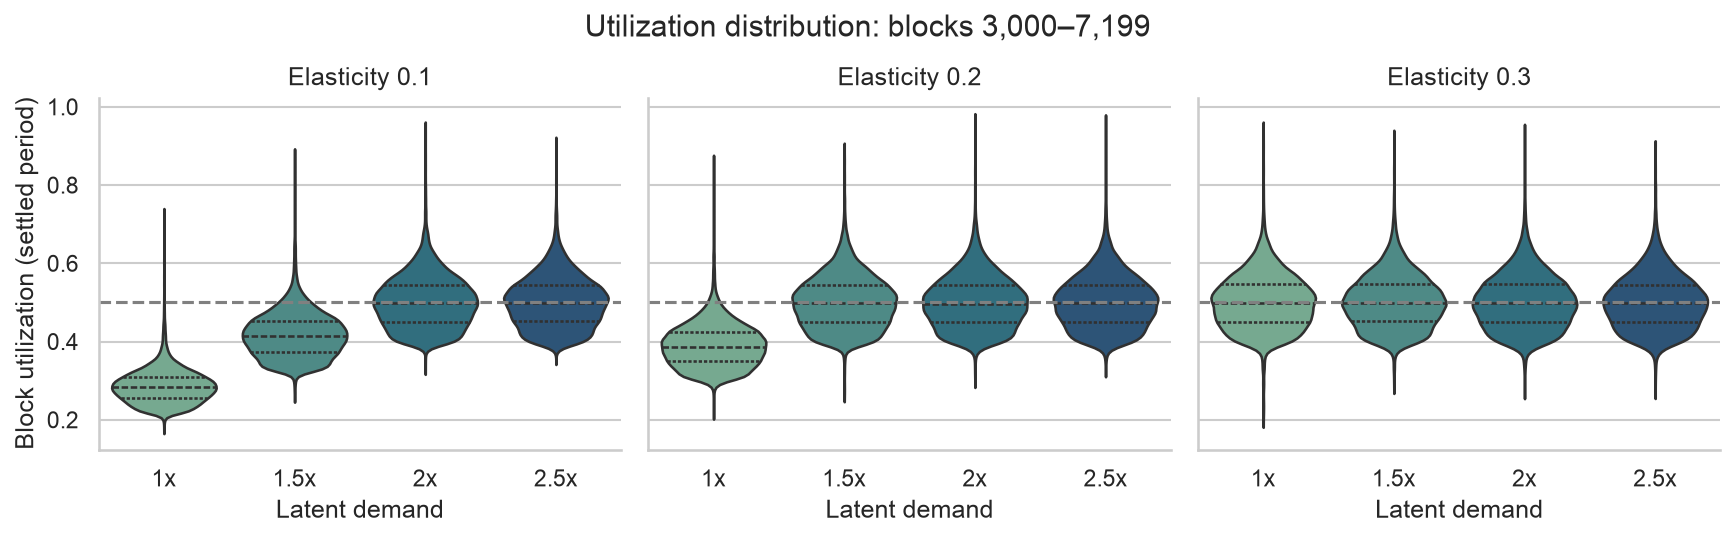

In [19]:
g = sns.catplot(
    data=steady_df,
    kind="violin",
    x="demand",
    y="utilization",
    order=demand_order,
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    legend=False,
    cut=0,
    inner="quartile",
    density_norm="width",
    height=3.4,
    aspect=1.15,
)
g.refline(y=0.5, color="grey")
g.set(xlabel="Latent demand", ylabel="Block utilization (settled period)")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Utilization distribution: blocks {steady_start:,}–{horizon - 1:,}", y=1.05)
plt.savefig(os.path.join(figs_dir, "utilization_distribution.png"), bbox_inches="tight")
plt.show()

In [20]:
print("blocks at >= 99% of the limit, worst cell:", round(cells_df["saturated_share"].max(), 5))
print("maximum utilization in the settled-period sample:", round(steady_df["utilization"].max(), 3))
steady_df.groupby(["elasticity", "demand"])["utilization"].describe(
    percentiles=[0.01, 0.5, 0.99]
)[["mean", "std", "1%", "50%", "99%"]].round(3)

blocks at >= 99% of the limit, worst cell: 0.0
maximum utilization in the settled-period sample: 0.982


mean    std     1%    50%    99%
elasticity demand                                   
0.1        1.5x    0.417  0.057  0.322  0.414  0.580
           1x      0.286  0.045  0.215  0.283  0.429
           2.5x    0.501  0.065  0.391  0.499  0.669
           2x      0.501  0.065  0.392  0.498  0.673
0.2        1.5x    0.500  0.067  0.387  0.497  0.673
           1x      0.390  0.056  0.297  0.387  0.547
           2.5x    0.501  0.067  0.386  0.498  0.675
           2x      0.501  0.067  0.386  0.497  0.676
0.3        1.5x    0.502  0.068  0.383  0.499  0.681
           1x      0.500  0.069  0.370  0.498  0.671
           2.5x    0.501  0.069  0.378  0.497  0.679
           2x      0.501  0.069  0.378  0.497  0.682

### Takeaways

- **The bulk shifts upward with demand at `e = 0.1`** and is already near the target
  across the whole `e = 0.3` panel.
- **No sampled settled-period block saturates.** The highest utilization in the
  20,000-block-per-cell sample is 98.2%; none reaches 99% of the limit.
- This is a sample statistic for `max(execution, state)` over blocks 3,000–7,199.
  The `execution_saturated_share` in `scenario_summary.csv` uses execution gas
  over all blocks, including the ramp, and ranges from about 0.0006% to 1.17%.
  These have different windows and accounting bases and should not be interchanged.

## Have fees and utilization stabilised?

Compare the first and second halves of blocks 3,000–7,199, the window used for
settled-period statistics. This diagnostic uses the full set of 24-block averages
across all paths; the reported scenario medians use sampled individual blocks.
The midpoint is rounded up to a bin boundary so no 24-block average is split.

Read both absolute and relative fee changes: a percentage move in a near-zero
base fee can be economically negligible. Small differences between the halves
support treating fees and utilization as approximately settled during this window.


In [21]:
settled_window_df = window_df[window_df["block"] >= steady_start].copy()
bin_width = int(np.diff(np.sort(window_df["block"].unique())).min())
midpoint = int(np.ceil(((steady_start + horizon) / 2) / bin_width) * bin_width)
early = settled_window_df[settled_window_df["block"] < midpoint]
late = settled_window_df[settled_window_df["block"] >= midpoint]

drift_df = (
    early.groupby(["elasticity", "demand"])[["base_fee_gwei", "utilization"]].median()
    .join(
        late.groupby(["elasticity", "demand"])[["base_fee_gwei", "utilization"]].median(),
        lsuffix="_early", rsuffix="_late",
    )
    .reset_index()
)
drift_df["fee_ratio"] = drift_df["base_fee_gwei_late"] / drift_df["base_fee_gwei_early"]
# Relative moves near zero can overstate the economic change. Read the absolute
# move alongside the ratio; neither alone establishes convergence.
drift_df["fee_change_gwei"] = drift_df["base_fee_gwei_late"] - drift_df["base_fee_gwei_early"]
drift_df["utilization_change_pp"] = (
    100 * (drift_df["utilization_late"] - drift_df["utilization_early"])
)
print(f"comparing blocks {steady_start:,}–{midpoint - 1:,} against {midpoint:,}–{horizon - 1:,}")
print("largest utilization move:", round(drift_df["utilization_change_pp"].abs().max(), 2), "pp")
print("largest relative fee move:", round((100 * (drift_df["fee_ratio"] - 1)).abs().max(), 2), "%")
print("largest absolute fee move:", round(drift_df["fee_change_gwei"].abs().max(), 4), "gwei")
drift_df[["elasticity", "demand", "base_fee_gwei_early", "base_fee_gwei_late",
          "fee_change_gwei", "fee_ratio", "utilization_change_pp"]].round(4)

comparing blocks 3,000–5,111 against 5,112–7,199
largest utilization move: 0.09 pp
largest relative fee move: 4.24 %
largest absolute fee move: 0.0071 gwei


,elasticity,demand,base_fee_gwei_early,base_fee_gwei_late,fee_change_gwei,fee_ratio,utilization_change_pp
0,0.1,1.5x,0.0000,0.0000,0.0000,1.0000,0.0495
1,0.1,1x,0.0000,0.0000,-0.0000,0.9816,0.0168
2,0.1,2.5x,0.3228,0.3225,-0.0004,0.9988,-0.0024
3,0.1,2x,0.0059,0.0061,0.0002,1.0289,-0.0403
4,0.2,1.5x,0.0022,0.0021,-0.0001,0.9576,-0.0332
5,0.2,1x,0.0000,0.0000,0.0000,1.0041,0.0499
6,0.2,2.5x,0.3688,0.3760,0.0071,1.0193,-0.0251
7,0.2,2x,0.0609,0.0611,0.0002,1.0032,0.0387
8,0.3,1.5x,0.0256,0.0258,0.0003,1.0108,-0.0542
9,0.3,1x,0.0002,0.0002,-0.0000,0.9826,0.0886


### Takeaways

- **Utilisation changes little between the two halves of the settled window.**
  The largest change in median utilisation is less than 0.09 percentage points.
- **Fees are also approximately stable.** The largest relative change is 4.24%;
  the largest absolute change is 0.0071 gwei, in `(e=0.2, 2.5x)`.
- The previously slow-adjusting `(e=0.1, 2.5x)` scenario moves from 0.3228 to
  0.3225 gwei, a change of about −0.12%. Its earlier recovery is excluded from
  the measurement window.
- These checks support using blocks 3,000–7,199 for the settled-period fee and
  utilization comparisons under this run's assumptions.

## Appendix: the full simulation window

These charts show the full 7,200-block day, including the ramp and the later
settling period. Each path is averaged within 24-block windows, giving 300
points per path. Lines show the mean across paths; shaded bands show the
10th–90th percentile of those window averages, rather than individual blocks.
The demand chart marks the end of the ramp and the approximate multiplier
needed to reach the 100M fee target under this transaction mix.


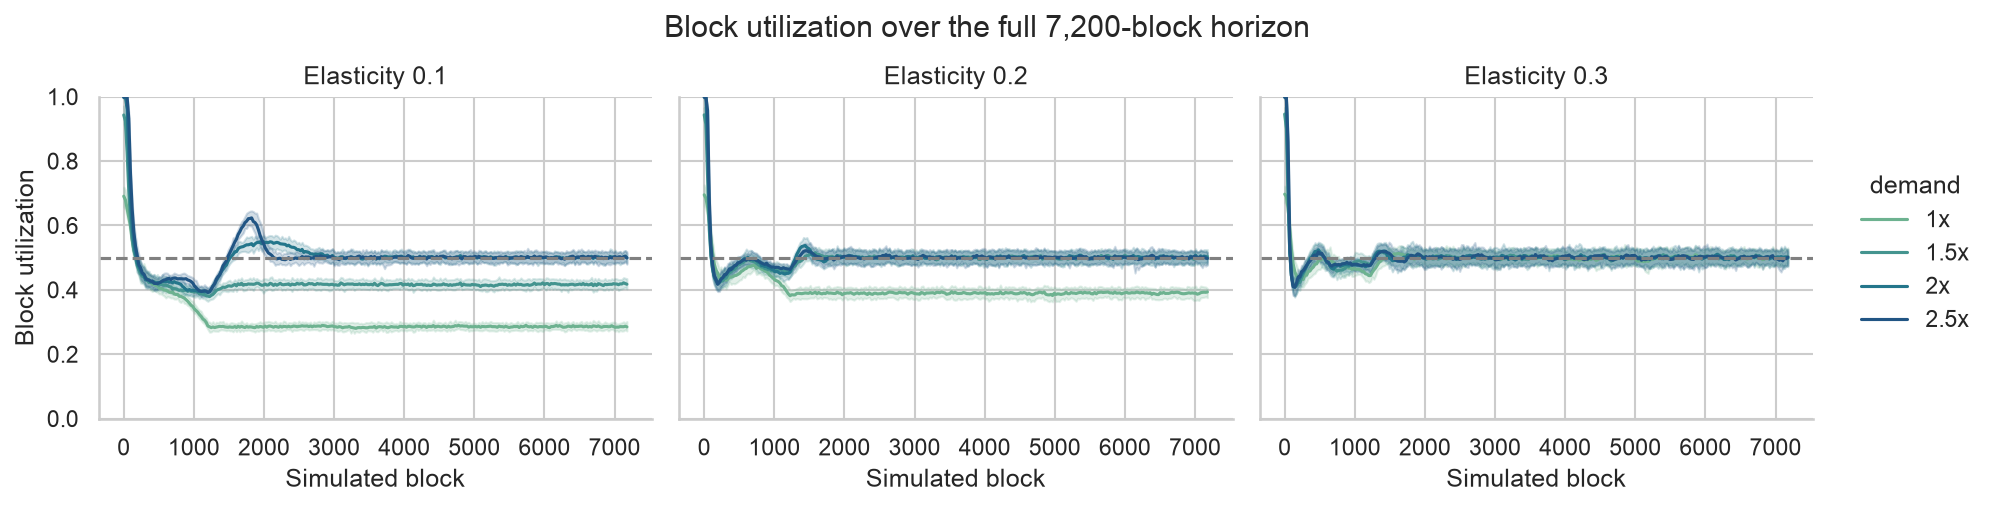

In [22]:
g = sns.relplot(
    data=window_df,
    kind="line",
    x="block",
    y="utilization",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=0.5, color="grey")
g.set(ylim=(0, 1), xlabel="Simulated block", ylabel="Block utilization")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Block utilization over the full {horizon:,}-block horizon", y=1.05)
plt.savefig(
    os.path.join(figs_dir, "appendix_full_window_utilization.png"), bbox_inches="tight"
)
plt.show()

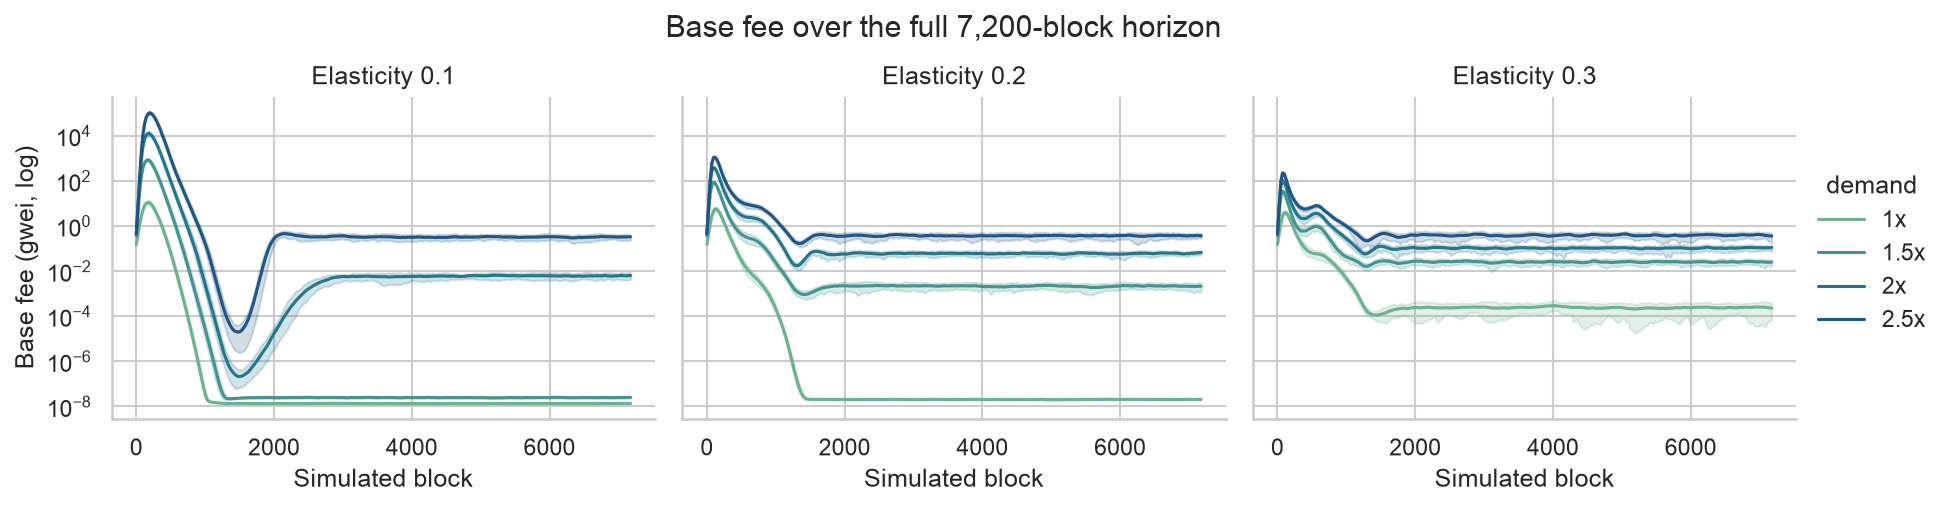

In [23]:
g = sns.relplot(
    data=window_df,
    kind="line",
    x="block",
    y="base_fee_gwei",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.set(yscale="log", xlabel="Simulated block", ylabel="Base fee (gwei, log)")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Base fee over the full {horizon:,}-block horizon", y=1.05)
plt.savefig(
    os.path.join(figs_dir, "appendix_full_window_base_fee.png"), bbox_inches="tight"
)
plt.show()

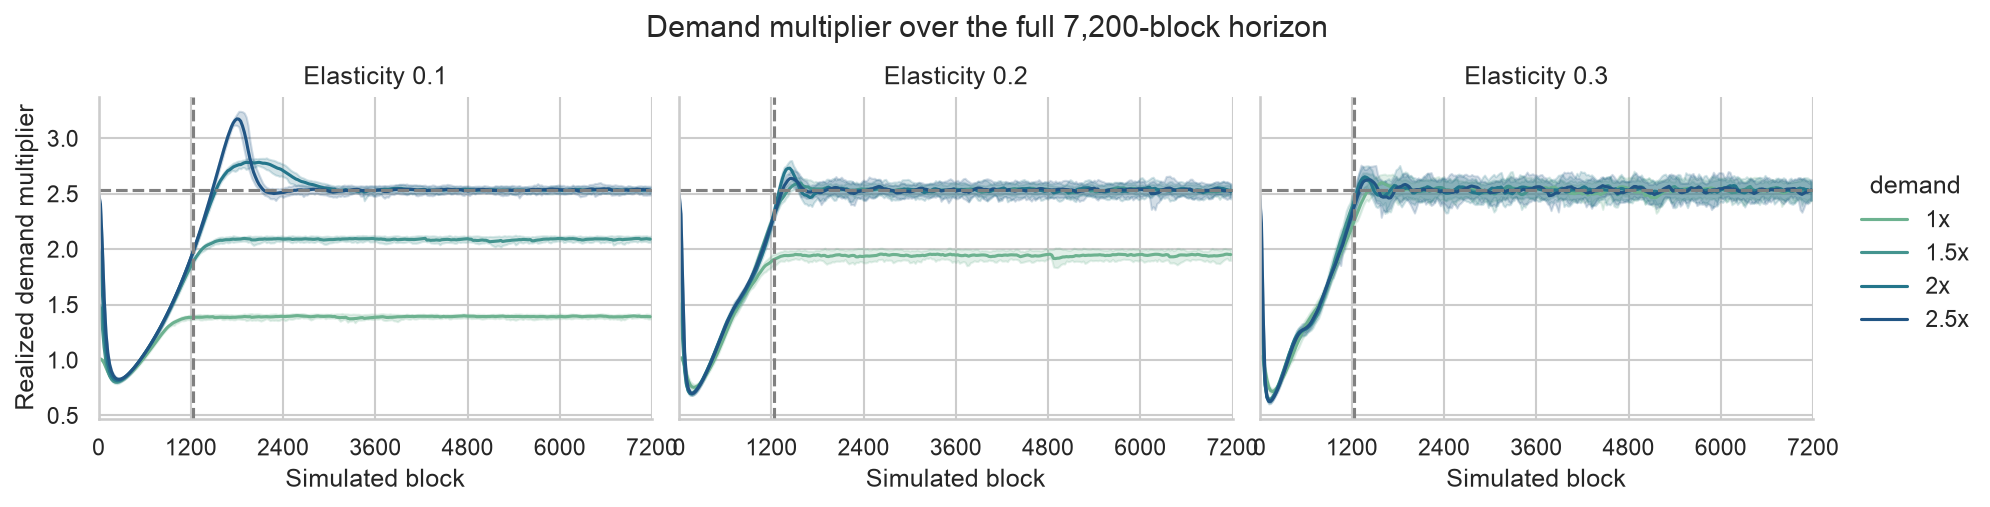

In [24]:
g = sns.relplot(
    data=window_df,
    kind="line",
    x="block",
    y="demand_multiplier",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=target_multiplier, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(xlim=(0, horizon), xticks=np.arange(0, horizon + 1, 1200), xlabel="Simulated block", ylabel="Realized demand multiplier")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Demand multiplier over the full {horizon:,}-block horizon", y=1.05)
plt.savefig(os.path.join(figs_dir, "appendix_full_window_demand_response.png"), bbox_inches="tight")
plt.show()

## Assumptions and limits

1. **Frozen execution and transaction mix.** Sampling does not re-execute
   transactions or enforce nonces, balances, state dependencies or bundles.
   It cannot predict how applications adapt to the repricing.
2. **An included-demand reference.** The trace omits never-included, replaced and
   dropped transactions. The 1x setting is an observed reference, not a measured
   total of potential demand after the fork. Submission times are unknown.
3. **Extrapolated price response.** One elasticity covers `execution + state`
   gas without substitution between dimensions. Estimates from historical daily
   data are applied at block frequency and much lower prices, using effective
   price rather than the empirical study's base-fee measure. No guard binds here.
4. **Untested transition choices.** Full demand applies from block 0 against
   60M capacity, with a 200-block EMA span. Gradual arrivals and alternative
   delays could change both the peak and adjustment; this sweep does not test them.
5. **One-day horizon.** The comparison of blocks 3,000–7,199 supports approximate
   settling within this window, not an equilibrium forecast or later stability.
6. **Queue delay does not deter arrivals.** Adapted fee caps apply on arrival,
   without subsequent rebidding. Small median queues do not rule out transient
   congestion, and terminal backlog is not a simulation of queue clearance.
7. **Capacity uses measured pre-refund gas, without gas-limit reservations.**
   Demand uses the sum of execution and state gas; utilisation uses their maximum.
   The 85.3% share of trace state gas in `schedule_gas_rescuable` rows depends on
   senders raising their signed gas limits sufficiently.
8. **One composition-pool width.** This run uses 16 neighbouring source cohorts
   per pool. Starts are sampled independently at each step, so historical demand
   persistence is not preserved. Pool width and sampling are untested sensitivities.

See [METHODOLOGY.md](METHODOLOGY.md) for the accounting and modelling details.